# N0 · What is generative modeling? — Building the evaluation ruler

> **Status:** ✅ **Complete.** Eye test + forward/reverse KL + Wasserstein-1 built and promoted to `toylab/`. O0, C0.1–C0.4 passed; exit questions E0 available as self-check.
>
> Part of the **1D generative-AI curriculum**. New session here? Read `CONTEXT.md` + `ROADMAP.md` first.
>
> **Key component of N0:** the *evaluation ruler* — the histogram-vs-true-`p` eye test, plus exact 1D **KL** and **Wasserstein** distances. We build nothing that *generates* yet; we build the thing we need to grade everything that will.

## The setup

Someone hands you a bag of scalars:

```
x = [-2.13, 1.94, 2.02, -1.88, 2.11, -2.04, ...]   # N of them, and nothing else
```

No labels. No `y`. Just numbers, drawn independently from some **target density** `p(x)` whose formula you are *not* shown. Your job across this entire curriculum: build machines that produce *new* numbers that look like they came from the same `p`.

In 1D we get a superpower we lose forever in high dimensions: we can **measure the gap to the truth exactly**. That measuring stick is what N0 forges. But before any exposition — three questions to surface what you already believe. **Answer them in chat.**

## 🎯 Opening questions — O0

**O0.1 · What's the deliverable?**
You're given the bag `{x_1, ..., x_N}` and nothing else. In your own words: what does it *mean* to \"learn a generative model\" of this data? What concrete thing(s) should a finished model be able to *do*?

**O0.2 · Two suspects.**
Alice's model can spit out new samples that look right, but cannot tell you the value of `p(x)` at a point. Bob's model can compute a number `p(x)` for any `x` you hand it, but isn't sure how to draw samples from it. Are **both** of these \"generative models\"? Why or why not?

**O0.3 · Grade with no answer key.**
You generate 1000 samples from your model and want to score them against the truth — but you have no labels and (pretend) no formula for `p`, only a large pile of *real* samples to compare against. Brainstorm: what could you actually *measure* to quantify \"these two piles of numbers came from the same distribution\"? List every idea you have.

### Your answer — O0

*(type here, or just answer in chat)*

> O0.1 — from the samples we can compute the likelihood of the samples to appear no? if they appear very often they need to get greater score? what happens in the other points is unknown and that is what the model has to be able to predict and might struggle? A finished model should be able to generate samples that resemble the initial sample distribution I have 
>
> O0.2 — It seems like Alice model can approximate p(x) by randomly sampling a lot of values and observing the frequency of each sample value? if it's continouus through a histogram by binning intervals. Bobs tells you directly p(x) so you can sample from the CDF (cumulative Distribution Function) but that would only get me the probability of p(x) < N_1 not sure I fully understand thsi way of sampling. So effectively both models can be used too obtain p(x) or generate samples so both are generative models 
>
> O0.3 — I would compare histograms or frequency between the 1000 samples and the real samples. The MSE between both frequencies (N/N_total_samples) would give me an estimate? To compare two pdf's we can also look at other methods like signal matching like correlation across the two histograms/pdfs/kde? 

## §1 · A target we secretly know

To grade ourselves we need a target whose answer we **secretly know** (`CONTEXT.md`: *toy target*). The canonical one: a **mixture of two Gaussians** at ±2 — *multimodal* (so it breaks naive models instructively), closed-form, and trivially plottable.

It exposes exactly two methods — the two capabilities you separated in **O0.2**:

| method | signature | what it is |
|---|---|---|
| `sample(key, n)` | `key, int → (n,)` | draw `n` fresh samples (the *Alice* power) |
| `log_prob(x)`    | `(n,) → (n,)`     | evaluate `log p(x)` at any points (the *Bob* power) |

The model we build in later notebooks **never** sees these. *We* hold them, to grade. (We work in `log` space throughout — densities multiply, log-densities add, and `logsumexp` keeps the mixture numerically stable.)

In [1]:
import jax
import jax.numpy as jnp
from jax import random

# --- The toy target: a 1D mixture of Gaussians, fully specified by 3 vectors. ---
# Two equal bumps at -2 and +2, each with std 0.7. We *secretly* know all of this.
weights = jnp.array([0.5, 0.5])   # mixing weights, must sum to 1
means   = jnp.array([-2.0, 2.0])  # bump centers
stds    = jnp.array([0.7, 0.7])   # bump widths


def log_prob(x):
    """log p(x), evaluated elementwise. x: (n,) -> (n,).
    p(x) = sum_k w_k * Normal(x; mean_k, std_k).  We compute it in log space."""
    x = jnp.atleast_1d(x)[:, None]                       # (n, 1) so it broadcasts over K bumps
    log_components = (                                    # (n, K): log of each weighted Gaussian
        jnp.log(weights)[None, :]
        - 0.5 * jnp.log(2 * jnp.pi)
        - jnp.log(stds)[None, :]
        - 0.5 * ((x - means[None, :]) / stds[None, :]) ** 2
    )
    return jax.scipy.special.logsumexp(log_components, axis=1)   # log-sum the K bumps -> (n,)


def sample(key, n):
    """Draw n samples. Two-step: pick a bump by weight, then sample that Gaussian."""
    key_pick, key_noise = random.split(key)              # explicit PRNGKey threading (our convention)
    comp = random.choice(key_pick, weights.shape[0], shape=(n,), p=weights)   # which bump each sample is from
    z = random.normal(key_noise, shape=(n,))             # standard normals
    return means[comp] + stds[comp] * z                  # shift+scale into the chosen bump


# quick sanity print (not the reveal yet)
key = random.PRNGKey(0)
xs = sample(key, 5)
print("5 samples:", jnp.round(xs, 2))
print("their log_prob:", jnp.round(log_prob(xs), 2))

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


5 samples: [-3.7099998  0.58       2.1399999  1.75       1.4699999]
their log_prob: [-4.24      -3.32      -1.28      -1.3199999 -1.55     ]


## 🤔 CHECKPOINT C0.1 — Predict-then-run

The next cell draws **5000** samples and overlays their density-normalized histogram on the true curve `p(x)`. **Before running it**, predict in chat:

1. **How many bumps**, centered roughly where? Symmetric?
2. **What fraction** of samples land left of `x = 0`?
3. The true density's **tallest point** — taller or shorter than a *single* Gaussian `N(0, 0.7²)` holding all the mass? Why? *(Hint: where did the mass go?)*
4. Out past `x = ±5`: what is `p(x)` doing, and what will the histogram do out there?

Commit your four predictions, **then** run.

### Your answer — C0.1

*(type here, or answer in chat)*

> 1. we have two bumps that are equally relevant to the composition of the mixture (same weights) with same std so same width. That means the pdf will be symmetric around the two centers at x=0
>
> 2. should be approx 50% of the samples left so 2500 left, 2500 right approx
>
> 3. I think should be shorter as the weights reduce it by 0.5 the normal as it gets distributed between the two
>
> 4. we just have tails probably so if we plot density histogram cause we look at (n_samples_in_bin/N_total) / dx ? so that will be low on the tails 

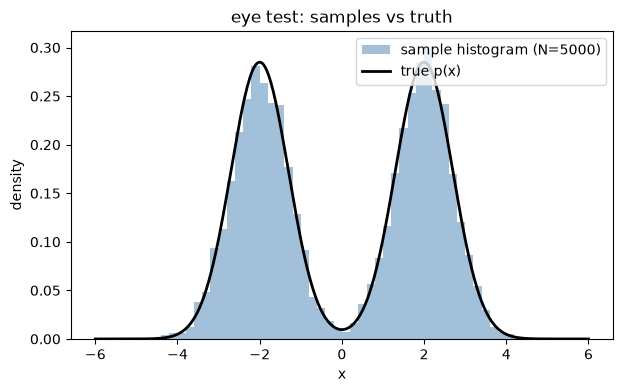

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- The eye test: density-normalized histogram of samples vs the true curve. ---
def plot_samples_vs_truth(samples, log_prob_fn, n_bins=60, x_range=(-6, 6), title=None):
    grid = jnp.linspace(x_range[0], x_range[1], 400)
    true_p = jnp.exp(log_prob_fn(grid))
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(np.asarray(samples), bins=n_bins, range=x_range, density=True,
            alpha=0.5, color="steelblue", label=f"sample histogram (N={len(samples)})")
    ax.plot(np.asarray(grid), np.asarray(true_p), color="black", lw=2, label="true p(x)")
    ax.set_xlabel("x"); ax.set_ylabel("density"); ax.legend()
    ax.set_title(title or "eye test: samples vs truth")
    plt.show()

samples = sample(random.PRNGKey(1), 5000)
plot_samples_vs_truth(samples, log_prob)

## §2 · From a picture to a number

The eye test (C0.1) is *necessary* but it's a **picture**, not a **score** — you can't rank twelve models by squinting at twelve plots. We need a scalar `D(model, truth)` that is small when they match and large when they don't.

In **O0.3** you proposed *MSE between histograms*. We flagged its flaw: it's **blind to the x-axis** (treats bins as unordered buckets). We now build the two rulers that fix this, each capturing a *different* meaning of "close":

| ruler | captures | one-liner |
|---|---|---|
| **KL divergence** | *information* gap | extra surprise from modeling `p` as `q`; **= what maximum-likelihood minimizes** (N1) |
| **Wasserstein-1** | *geometry* gap | how far you must **shovel mass** to turn one pile into the other |

We build **KL** now.

### Ruler #1 · KL divergence

For a truth density `p` and a model density `q`:

$$\mathrm{KL}(p \,\|\, q) \;=\; \int p(x)\,\log\frac{p(x)}{q(x)}\,dx \;=\; \mathbb{E}_{x\sim p}\big[\log p(x) - \log q(x)\big].$$

Read it as: **the average extra surprise (in nats) you suffer when reality is `p` but you modeled it as `q`.** Three facts to carry:

- **Non-negative:** `KL(p‖q) ≥ 0`, with `= 0` **iff** `p = q` (Gibbs' inequality). So *smaller is better, zero is perfect.*
- **Asymmetric:** `KL(p‖q) ≠ KL(q‖p)` in general — it is **not** a distance. The two directions even have nicknames (*mode-covering* vs *mode-seeking*) we'll meet in the break-it.
- The expectation is **under `p`**: the integrand is weighted by `p(x)`, so KL only "cares" about `q` where `p` actually has mass.

**Estimate it in 1D by binning** — exactly your O0.3 instinct, but with the *right* per-bin combination instead of MSE: chop the axis into bins, turn each density into a probability vector (`p_i` = mass in bin `i`), and sum

$$\mathrm{KL}(p\|q) \approx \sum_i p_i \,\log\frac{p_i}{q_i}.$$

In [8]:
# --- Ruler #1: KL divergence via binning ---
def to_hist(samples, edges):
    """Bin samples into a NORMALIZED probability vector over the given bin edges."""
    counts, _ = jnp.histogram(samples, bins=edges)
    return counts / counts.sum()

def kl_divergence(p, q, eps=1e-12):
    """KL(p || q) for two probability vectors:  sum_i p_i * log(p_i / q_i)."""
    p = p + eps; q = q + eps          # nudge off zero so log is finite...
    p = p / p.sum(); q = q / q.sum()  # ...then renormalize. (We INTERROGATE this 'fix' in C0.3.)
    return jnp.sum(p * jnp.log(p / q))

# sanity: a PERFECT model (same target, different seed) should score ~0
edges  = jnp.linspace(-6, 6, 61)              # 60 bins
real   = sample(random.PRNGKey(1), 20_000)
modelA = sample(random.PRNGKey(2), 20_000)    # a flawless 'model' = the truth itself
p = to_hist(real, edges)
qA = to_hist(modelA, edges)
print(f"KL(real || perfect-model) = {float(kl_divergence(p, qA)):.5f}   (want ~0; the rest is sampling noise)")

KL(real || perfect-model) = 0.00368   (want ~0; the rest is sampling noise)


## 🤔 CHECKPOINT C0.2 — Hand-compute

Do this **by hand** (natural log; `ln 2 ≈ 0.693`, `ln 3 ≈ 1.099`, `ln 1.5 ≈ 0.405`). Two bins only:

$$p = [\,0.5,\; 0.5\,], \qquad q = [\,0.25,\; 0.75\,].$$

- **(a)** Compute `KL(p‖q) = Σ_i p_i ln(p_i/q_i)`.
- **(b)** Compute `KL(q‖p)`.
- **(c)** Are (a) and (b) equal? What does that say about calling KL a *"distance"*?
- **(d)** Both came out **positive**. Coincidence, or guaranteed? Which of the three facts above pins it down?

Show your arithmetic in chat — I'm grading the *steps*, not just the number.

### Your answer — C0.2

*(type here, or answer in chat)*

> (a) KL(p‖q) = 0.14  = 0.5 ln(0.5/0.25) + 0.5 * ln(0.5/0.75)
>
> (b) KL(q‖p) = 0.13 = 0.25 ln(0.25/0.5) + 0.75 * ln(0.75/0.5)
>
> (c) Not equal is not symmetric 
>
> (d) Both positive is guarnateed 

### §2b · The asymmetry has teeth

We proved `KL(p‖q) ≠ KL(q‖p)`. That's not pedantry — the two directions are *different objectives*, each with a name:

- **Forward KL** `KL(p‖q)` — averaged under the **truth** `p`. *(This is the maximum-likelihood objective — N1.)*
- **Reverse KL** `KL(q‖p)` — averaged under the **model** `q`. *(Shows up in variational / adversarial training.)*

Two questions, one experiment answers both:

1. **Can the two directions *disagree* about which of two models is better?** If yes, then *"which model is best?"* has **no answer until you name the ruler** — the capstone thesis, in miniature, already in N0.
2. **The `eps` band-aid.** Our `kl_divergence` quietly adds `eps=1e-12` before the log. Drop it (`eps=0`) and let one bin be exactly zero while the truth there is positive: that term is `p_i · log(p_i / 0) = +∞`. So **KL can be literally infinite** — and our 'fix' both *hides* it and makes the answer depend on the arbitrary `eps`. Your **C0.1.4** tail trap (smooth-positive truth vs zero-or-jagged histogram) is exactly where this goes off.

## 🤔 CHECKPOINT C0.3 — Break-it (predict, then run the demo)

Truth `p` = the two bumps at ±2. Two *flawed* single-Gaussian models:

- **W** = `N(0, 3²)` — *wide*: covers both bumps, but dumps mass in the empty valley at `x=0`.
- **N** = `N(2, 0.7²)` — *narrow*: nails the **right** bump, assigns ≈0 to the **entire left** bump.

Predict **before running** the demo cell:

- **(a)** Under **forward** `KL(p‖q)` (avg under *truth*): which scores worse, **W** or **N**? Why — *where does the integrand blow up?*
- **(b)** Under **reverse** `KL(q‖p)` (avg under *model*): which scores worse now? Why — *where does `q` stray to a region with `p≈0`?*
- **(c)** A raw empirical **histogram** of truth has exactly-zero tail bins. Is forward `KL(truth‖histogram)` finite or infinite, and *which single term* causes it?
- **(d) Connect (→ syllabus):** one direction makes a model *spread to cover every mode*, the other makes it *collapse onto one*. Attach the nicknames **mode-covering** / **mode-seeking** to *forward* / *reverse* — and bet which later family (say **GANs** vs plain **MLE**) shows which pathology.

### Your answer — C0.3

*(type here, or answer in chat)*

> (a) I believe that N would do better as it aligns with half of the mixture even if the mixture is 0.5 - So worse W. But it seems like when q approaches 0 the log p/q , that goes to infty so not sure... honestly can you even compute it? I am lost here
>
> (b)
>
> (c)
>
> (d) I got that yes mode covering comes from the forward p||q cause you penalize points where the function q is 0 where p is relevant whereas reverse q||p penalizes points where the p is 0 and q is relevant (mode seeking)

                       W=N(0,3) wide    N=N(2,0.7) narrow
forward  KL(truth||q):      0.510           7.476
reverse  KL(q||truth):      1.889           0.687
  -> forward prefers W (cover both)   |   reverse prefers N (collapse to one)
the landmine, literal:  KL([0.5,0.5] || [1.0,0.0]) with eps=0  = inf


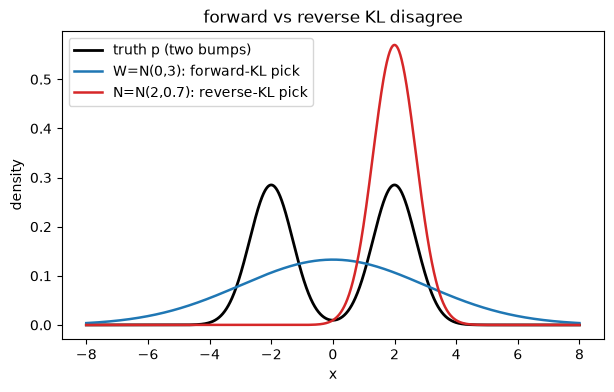

In [9]:
# --- §2b demo: two flawed models x two directions of KL  (run AFTER predicting) ---
def gauss_logpdf(x, mu, sigma):
    return -0.5*jnp.log(2*jnp.pi) - jnp.log(sigma) - 0.5*((x-mu)/sigma)**2

grid = jnp.linspace(-8, 8, 1601); dx = grid[1]-grid[0]
p_true = jnp.exp(log_prob(grid))
qW = jnp.exp(gauss_logpdf(grid, 0.0, 3.0))   # Wide: covers both, fills the valley
qN = jnp.exp(gauss_logpdf(grid, 2.0, 0.7))   # Narrow: nails right bump, misses left

def kl_grid(a, b):                            # KL(a||b) from densities on a shared grid
    pa = a*dx; pb = b*dx; pa = pa/pa.sum(); pb = pb/pb.sum()
    mask = pa > 0
    return float(jnp.sum(jnp.where(mask, pa*jnp.log(pa/jnp.where(pb>0, pb, 1.0)), 0.0)))

print("                       W=N(0,3) wide    N=N(2,0.7) narrow")
print(f"forward  KL(truth||q):    {kl_grid(p_true,qW):7.3f}         {kl_grid(p_true,qN):7.3f}")
print(f"reverse  KL(q||truth):    {kl_grid(qW,p_true):7.3f}         {kl_grid(qN,p_true):7.3f}")
print("  -> forward prefers W (cover both)   |   reverse prefers N (collapse to one)")
print("the landmine, literal:  KL([0.5,0.5] || [1.0,0.0]) with eps=0  =",
      float(kl_divergence(jnp.array([0.5,0.5]), jnp.array([1.0,0.0]), eps=0.0)))

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(np.asarray(grid), np.asarray(p_true), 'k',  lw=2,   label='truth p (two bumps)')
ax.plot(np.asarray(grid), np.asarray(qW),     'C0', lw=1.8, label='W=N(0,3): forward-KL pick')
ax.plot(np.asarray(grid), np.asarray(qN),     'C3', lw=1.8, label='N=N(2,0.7): reverse-KL pick')
ax.set_xlabel('x'); ax.set_ylabel('density'); ax.set_title('forward vs reverse KL disagree')
ax.legend(); plt.show()

### 📎 Aside — why C0.3 was the *whole game* (forward KL = MLE, reverse ≈ GAN)

What does **MLE** (maximum likelihood) have to do with any of this? Everything (proved properly in **N1**):

> **Maximum likelihood = minimizing forward KL.** Maximizing `Σ_i log q_θ(x_i)` (make the real data probable under the model) equals minimizing `KL(p‖q_θ)`, because `KL(p‖q) = −H(p) − E_p[log q]` and only the second term depends on `θ`.

So the training objective of a whole family **is** forward KL ⇒ they inherit **mode-covering** (cover every mode, over-smooth, never drop one). **GANs** instead minimize a **JS** divergence and empirically behave **mode-seeking** ⇒ **mode collapse** (model *N*: nail one mode, abandon the rest). *(GAN↔reverse-KL is intuition, made exact in N5.)*

| family | trains by | tendency | classic failure |
|---|---|---|---|
| MLE: flows (N2), AR (N3), VAE (N4) | **forward** KL `(p‖q)` | mode-**covering** | blur / over-smooth |
| GAN (N5) | JS (≈ reverse-KL-ish) | mode-**seeking** | **mode collapse** |

W = the forward-KL/MLE pick; N = the reverse-KL/GAN pick. And **WGAN** swaps in the **W1** metric we build next to defuse mode collapse.

### 📎 Aside (cont.) — forward vs reverse is decided by *one* thing

Both directions contain *both* logs. The only difference is **which density is the weight out front** = **which distribution you sample from**:

$$\mathrm{KL}(p\|q)=\int p\,\log\tfrac{p}{q}\;\;(\text{weight }p) \qquad \mathrm{KL}(q\|p)=\int q\,\log\tfrac{q}{p}\;\;(\text{weight }q)$$

**MLE samples from `p`** (your dataset is real data) ⇒ `(1/N)Σ log q(x_i) ≈ E_{x∼p}[log q]` ⇒ **forward, always.** You never do reverse by accident: reverse needs samples *from your model `q`*, scored under the *true `p`* — a different algorithm, needing access to true `p` you usually don't have. (The `log p` in forward KL is the constant `−H(p)`; MLE just drops it.)

**Penalty asymmetry — the whole personality of each direction:**

| region | forward `KL(p‖q)` (wt `p`) | reverse `KL(q‖p)` (wt `q`) |
|---|---|---|
| `q≈0` where `p` big (**missed mode**) | **∞** → *cover every mode* | ≈0, free → collapse OK |
| `q` big where `p≈0` (**valley leak**) | ≈0, free → over-spread OK | **∞** → *stay on real mass* |

Your *"MLE doesn't penalize what happens where `p` is unknown"* = the **bottom-left** cell: forward shrugs at valley-leak, screams at missed modes ⇒ **mode-covering / over-smooth**. Reverse is the mirror ⇒ **mode-seeking / collapse**.

### 📎 Aside — the two KL directions are *precision* and *recall*

Train however you like, then **grade with BOTH directions** — each catches a failure the other is blind to:

- **forward `KL(p‖q)`** (weight `p`) ↑ ⟺ `q` **missed mass `p` has** ⟺ **dropped mode** ⟺ low **RECALL**.
- **reverse `KL(q‖p)`** (weight `q`) ↑ ⟺ `q` **put mass where `p≈0`** ⟺ **hallucination / valley-leak** ⟺ low **PRECISION**.

Straight off our two flawed models (the exact numbers from §2b / §3):

| model | forward `KL(p‖q)` | reverse `KL(q‖p)` | reading |
|---|---|---|---|
| **N** (collapsed to 1 bump) | **7.476** (bad recall) | 0.687 (good precision) | *says little, all true* |
| **W** (over-spread) | 0.510 (good recall) | **1.889** (bad precision) | *covers all, babbles in valley* |

So *"is my model missing a mode?"* is a **forward-KL / recall** question (and it's what MLE already minimizes); *"is my model hallucinating?"* is a **reverse-KL / precision** question (the axis MLE never touched — worth checking *after* training).

**Catch:** both need the **true `p`** at your samples — which you only have in toy-land. Real high-D problems approximate this exact two-sided idea *without* `p`: it's the **precision & recall for generative models** framework. Two orthogonal numbers, not one — the capstone thesis again.

## §3 · Ruler #2 — Wasserstein-1 (earth-mover)

KL just bit us three ways: **asymmetric** (not a distance), can be **∞** (disjoint/zero support), and its histogram cousin is **x-axis-blind** (your O0.3 worry). **Wasserstein-1 fixes all three.**

**The picture.** Treat `p` and `q` as two piles of dirt of equal total mass. `W1(p,q)` = the **minimum work** to reshape pile `p` into pile `q`, where *work = mass moved × distance moved*. Literally "how far must I shovel the mass."

That's why it **sees the x-axis**: shoving mass 1 unit is cheap, 10 units is expensive — the exact sensitivity MSE-on-bins lacked. And because it only ever *measures distances*, it's **symmetric**, always **finite**, and a true **metric** (obeys the triangle inequality).

### The 1D miracle: sort, then average

In general dimension, optimal transport is a hard optimization. In **1D it collapses to sorting.** Two equivalent forms:

1. **CDF form:** `W1(p,q) = ∫ |F_p(x) − F_q(x)| dx` — the **area between the two CDFs**.
2. **Sample form:** for two **equal-size** sample sets — *sort both, pair in order, average the gaps*: `W1 = mean_i |a_(i) − b_(i)|`.

**Why sorting is optimal.** The cheapest transport plan never lets two paths **cross**. If a low source shipped to a high target while a high source shipped to a low target, you could *uncross* them and strictly cut total distance (a rearrangement inequality). No crossings ⟺ monotone ⟺ *i*-th smallest maps to *i*-th smallest ⟺ **sort and pair**.

In [10]:
# --- Ruler #2: Wasserstein-1  (reuses grid, p_true, qW, qN from the §2b demo — run that first) ---
def wasserstein1(a, b):
    """W1 between two EQUAL-size 1D sample sets: sort, pair in order, average the gaps."""
    return jnp.mean(jnp.abs(jnp.sort(a) - jnp.sort(b)))

def wasserstein1_cdf(pdf_a, pdf_b, grid):
    """W1 between two densities on a shared grid = area between their CDFs."""
    dx = grid[1] - grid[0]
    Fa = jnp.cumsum(pdf_a) * dx; Fb = jnp.cumsum(pdf_b) * dx
    Fa = Fa / Fa[-1]; Fb = Fb / Fb[-1]                 # make them proper CDFs (end at 1)
    return jnp.sum(jnp.abs(Fa - Fb)) * dx

# the same two flawed models, but now a ruler that can't blow up or self-contradict
print(f"W1(truth, W=N(0,3))   = {float(wasserstein1_cdf(p_true, qW, grid)):.3f}")
print(f"W1(truth, N=N(2,0.7)) = {float(wasserstein1_cdf(p_true, qN, grid)):.3f}   (finite, symmetric, ONE number per model)")

W1(truth, W=N(0,3))   = 0.820
W1(truth, N=N(2,0.7)) = 2.000   (finite, symmetric, ONE number per model)


## 🤔 CHECKPOINT C0.4 — Hand-compute + Connect

**Part 1 · why sort.** Two piles, two samples each: `a = {0, 10}`, `b = {10, 0}`.
- **(a)** Pair them **in the given index order** and average `|a_i − b_i|`.
- **(b)** Now **sort** each pile, then pair and average.
- **(c)** The two piles are *the same set*. Which answer is the true `W1`, and what does the gap between (a) and (b) say about *why* 1D optimal transport sorts?

**Part 2 · geometry vs ∞.** Pile `a = {0,0,0}`, pile `b = {d,d,d}` (all mass at distance `d`).
- **(d)** What is `W1(a,b)` as a function of `d`? What is `KL` between them (as histograms)? Which property of `W1` — that `KL` lacks — does this expose?

**Part 3 · connect.**
- **(e)** Match each `W1` property to the KL pain it cures: *symmetric* → ?  ·  *finite on disjoint support* → ?  And which **GAN variant** (you just met it) is named after this metric, and what failure was it built to fix?

### Your answer — C0.4

*(type here, or answer in chat)*

> (a) result is 10
>
> (b) if we sort is 0 
>
> (c) the true W1 is b cause you hav to sort the samples first. This means we had to move 0 mass to get similar samples? 
>
> (d) is W1(a,b)=' the result for KL is infty that is the problem when one of the two is 0 valued you get log(0) which is infty and you are cooked
>
>
> (e) W1 I think does not care about symmetry or x-axis at all cause we are doing sample-to-sample comparison? 

In [ ]:
# --- C0.4 confirm (run AFTER your hand-computes) ---
a = jnp.array([0., 10.]); b = jnp.array([10., 0.])
naive = float(jnp.mean(jnp.abs(a - b)))                 # pair in given order
print(f"identical piles a={{0,10}}, b={{10,0}}:  naive index-pair = {naive:.1f}   sorted W1 = {float(wasserstein1(a,b)):.1f}")

for d in (1., 3., 7.):                                  # disjoint point masses, growing apart
    aa = jnp.zeros(3); bb = jnp.full(3, d)
    print(f"a={{0,0,0}}, b={{{d:.0f},{d:.0f},{d:.0f}}}:  W1 = {float(wasserstein1(aa,bb)):.1f}   (KL here = +inf)")

## §4 · Promote the toolkit into `toylab/`

We hand-built three kinds of thing in this notebook: a **target** (`sample`/`log_prob`), the **eye test** (`plot_samples_vs_truth`), and the **rulers** (`to_hist`, `kl_divergence`, `kl_grid`, `wasserstein1`, `wasserstein1_cdf`). Every one is *infrastructure* — un-interesting scaffolding identical across notebooks — so it graduates into the shared module:

```
toylab/
├── targets.py   # Mixture1D, two_bumps   (each exposes sample + log_prob)
├── viz.py       # plot_samples_vs_truth
└── metrics.py   # to_hist, kl_divergence, kl_grid, wasserstein1, wasserstein1_cdf
```

**Hard rule (CONTEXT.md):** a *method* — any training objective, model, or sampler-of-a-model — **never** moves here. Those stay visible in their notebook. `toylab` holds only the ruler and the playground. From N1 on we just `import toylab` and spend our attention on the generative idea.

model   fwd KL(p||q)   rev KL(q||p)      W1


TypeError: kl_grid() missing 1 required positional argument: 'grid'

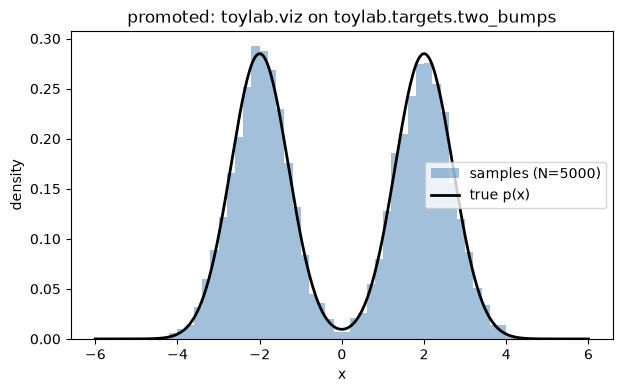

In [12]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))      # repo root -> `import toylab` works from notebooks/
from toylab import two_bumps, plot_samples_vs_truth, kl_grid, wasserstein1_cdf
import jax.numpy as jnp
from jax import random

# 1) the eye test, now entirely from the promoted module
plot_samples_vs_truth(two_bumps.sample(random.PRNGKey(0), 5000), two_bumps.log_prob,
                      title="promoted: toylab.viz on toylab.targets.two_bumps")

# 2) the WHOLE evaluation ruler, in a handful of lines, on our two flawed models
grid  = jnp.linspace(-8, 8, 1601)
gauss = lambda x, mu, s: jnp.exp(-0.5*jnp.log(2*jnp.pi) - jnp.log(s) - 0.5*((x-mu)/s)**2)
p  = jnp.exp(two_bumps.log_prob(grid))
qW = gauss(grid, 0.0, 3.0)     # wide  (mode-covering pick)
qN = gauss(grid, 2.0, 0.7)     # narrow (mode-seeking pick)
print("model   fwd KL(p||q)   rev KL(q||p)      W1")
for name, q in [("W", qW), ("N", qN)]:
    print(f"  {name}      {float(kl_grid(p,q,grid)):8.3f}      {float(kl_grid(q,p,grid)):8.3f}     {float(wasserstein1_cdf(p,q,grid)):.3f}")
print("\nforward & reverse KL disagree (W vs N); W1 gives one verdict. That tension is the point.")

## 🏁 Exit questions — E0 (the harder closing set)

You now hold **four instruments**: the *eye test*, *forward KL* `(p‖q)`, *reverse KL* `(q‖p)`, and *W1*.

**E0.1 · Reach for the right ruler.** Name the **one** you grab first, + one sentence why:
- (i) "Quick gut check — is my trained model even *roughly* right?"
- (ii) "Did my model silently **drop a mode** of the data?"
- (iii) "Is my model **hallucinating** samples where the data never goes?"
- (iv) "Early in training my samples and the data **don't overlap at all**, and my KL loss is stuck at ∞ with no gradient — I need a loss that still *pulls*."

**E0.2 · Is W1 simply the best, then?** Forward- and reverse-KL crowned *different* models; W1 gives a single verdict. Does that make W1 the **one true ruler** to use everywhere? Argue *both* sides — and say what it implies for the **shape** the capstone's eventual "which method is best?" answer must take.

**E0.3 · Why this whole course exists (the 1D payoff).** Every ruler here was exact *because* we are in 1D. For each, does it **survive to high dimensions** (e.g. images), and what breaks first?
- the eye test · binned KL · W1-by-sorting
- And the kicker: what do **all** of them secretly require that you simply **do not have** in a real high-dimensional problem?

### Your answer — E0

*(type here, or answer in chat)*

> E0.1 — 

(i) - as a quick gut check you can plot density plot q(x) (from samples or directly given by the generative model) vs ground truth samples p(x)? So you do eye test

(ii) - to see if your model dropped a mode you want to do forward KL - KL(q||p) cause you penalize where q(x) is 0 and p is high
 
(iii) - if you want to see if your model hallucinates where p() the reverse KL works perfect penalizing where p is 0 and q is high

(iv) - early in the training maybe the samples and the data do not overlap cause the model sucks? then you can use W1 score? 
>
> E0.2 — W1 is available across the board that is true but 
>
> E0.3 —

## 🟢 N0 — Summary & what carries forward

**The frame.** We only ever observe a bag of unlabeled scalars `{x_i}` from an unknown **target density `p(x)`**. A *generative model* produces **new** samples resembling `p` (and, for some families, evaluates `p`). The two capabilities — **sample** and **evaluate-density** — are how we'll taxonomize every family in the syllabus.

**Why N0 first.** Before building anything that generates, build the **ruler**. In 1D we can measure the gap to truth *exactly and cheaply* — that is the entire reason we work in 1D. Toy target: a 2-bump mixture of Gaussians at ±2 (multimodal → breaks naive models; closed-form; plottable).

**Three rulers (now living in `toylab`):**

1. **Eye test** — density histogram vs the true curve. Qualitative; necessary but can't *rank* models.
2. **KL divergence** — the *information* gap. `KL(p‖q)=E_{x∼p}[log p − log q]`; `≥0`, `=0` iff `p=q` (Gibbs); **asymmetric** ⇒ a *divergence*, not a metric.
   - **forward `KL(p‖q)`** (avg under truth) = **mode-covering / recall** = *exactly what MLE minimizes*; `→∞` for a **missed mode**.
   - **reverse `KL(q‖p)`** (avg under model) = **mode-seeking / precision** ≈ GAN behavior; `→∞` for **hallucinated** mass.
   - forward vs reverse is decided by **which distribution you sample from** (the weight out front), not which logs appear. `MLE = max Σ log q(x_i) = min forward KL`.
   - Both directions need the **true `p`** (toy-only); real high-D proxy = *precision/recall for generative models*.
   - **Pains:** asymmetric · can be **∞** on disjoint support · **distance-blind** (sees per-bin ratios, not how *far* mass is misplaced) · estimator is binning-sensitive.
3. **Wasserstein-1** — the *geometry* gap = earth-mover (min mass×distance to reshape `p` into `q`). `W1 = ∫|F_p − F_q| dx =` (from samples) **sort-both-and-average-the-gaps** — the same quantity; sorting is optimal because 1D OT is monotone (no crossings). **Cures all three KL pains:** *symmetric* (one verdict) · *finite on disjoint support* (`W1=d`, a usable gradient → **WGAN**) · *distance-aware* (sees the x-axis).

**The punchline (numbers).** Wide `W=N(0,3)` vs narrow `N=N(2,0.7)` against the 2-bump truth:

| model | forward KL | reverse KL | W1 |
|---|---|---|---|
| **W** (over-spread) | **0.510** | 1.889 | 0.820 |
| **N** (collapsed) | 7.476 | **0.687** | 2.000 |

The two KL directions **crown different models** (forward→W, reverse→N); W1 gives one verdict. ⇒ **"best" is not a scalar — it depends on the criterion you name.** (The capstone thesis, arriving in N0.)

**Exit synthesis (E0).** (i) gut-check → *eye test*; (ii) missed mode → *forward KL / recall*; (iii) hallucination → *reverse KL / precision*; (iv) disjoint supports / no gradient → *W1*. And every ruler is exact **only because we are in 1D**: the eye test (can't plot high-D), binned KL (curse of dimensionality), and W1-by-sorting (sorting is 1D-only) **all break** in high dimensions — and all secretly need the **true `p`** you won't have. *That gap is why the rest of the course exists.*

**→ N1.** Forward KL stops being a *grading* tool and becomes the *training* objective: fit a parametric `q` to `two_bumps` by **maximum likelihood**.